# 01 — Data audit: what the raw telemetry actually looks like

**Session 3 (`pipeline_v2/`).** Sessions 1 and 2 froze the data pipeline and worked on models,
cross-validation and metrics. That work ended at a wall: every leader landed at **PR-AUC ≈ 0.078–0.086**,
about **2× the 0.0403 random baseline**, and Session 2 concluded that going further needs changes to the
*pipeline*, not more tuning.

This session rebuilds the pipeline from scratch. Before changing anything, this notebook measures the raw
data — because several decisions inherited from Session 1 rest on assumptions the data does not support.

**What is fixed and cannot move (the time notions developed in Session 2):**

1. prediction is **per window**, never per job — the dataset is never collapsed to one row per job;
2. labels are **time-based** — a snapshot is positive iff its job ends in a failure state and it falls
   within a horizon before that end;
3. the train/test split is **temporal**, by job end date;
4. selection uses a **temporal holdout** plus **purged time-series CV** — never shuffled, never merely grouped;
5. every window carries its own **end timestamp**.

**What is on the table:** which metrics, how they are transformed, how a window is summarised, the window
size, the horizon, the stride, and the definition of the positive class.

Nothing here reads Session 1/2 code or artifacts. Their published *numbers* are quoted for comparison only.

In [1]:
import sys, json, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq, pyarrow.compute as pc

sys.path.insert(0, str(Path.cwd().parent))
import pv2
pv2.style()
AUDIT = {}
files = sorted(pv2.DATASET.glob("*.parquet"))
print("source parquet:", pv2.DATASET, f"({len(files)} partitions)")
print("window", pv2.WINDOW, "| horizon", pv2.HORIZON_H, "h | train fraction", pv2.TRAIN_FRACTION)

source parquet: D:\_fcall\UNIFEI\tcc\hpc_workload\dataset\prom_slurm_joined\prom_slurm_joined.parquet (200 partitions)
window 40 | horizon 2.0 h | train fraction 0.8


## 1. The population

GPU nodes only, `CANCELLED` jobs excluded (a cancellation says nothing about node health). The key columns
of every surviving snapshot are cached once as `artifacts/scaffold.parquet`, so the rest of this audit
never touches the 10 GB parquet again.

In [2]:
t0 = time.time()
sc, jt = pv2.build_scaffold()
print(f"{time.time()-t0:.1f}s")
print(f"snapshots {len(sc):,} | jobs {len(jt):,} | GPU nodes {jt['node'].nunique()}")
print(f"monitored span {sc['timestamp'].min()} .. {sc['timestamp'].max()}")

by_state = jt.groupby("state", observed=True).agg(jobs=("slurm_id", "size"),
                                                  snapshots=("n_snap", "sum"))
by_state["snap_share"] = by_state["snapshots"] / by_state["snapshots"].sum()
print(by_state.sort_values("jobs", ascending=False).to_string())

AUDIT["n_snapshots"] = len(sc); AUDIT["n_jobs"] = len(jt)
AUDIT["n_nodes"] = int(jt["node"].nunique())
AUDIT["span"] = [str(sc["timestamp"].min()), str(sc["timestamp"].max())]

scaffold cached -> scaffold.parquet, job_table.parquet


13.1s


snapshots 11,144,842 | jobs 23,618 | GPU nodes 51


monitored span 2022-08-25 10:27:00 .. 2022-11-01 13:58:00


                jobs  snapshots  snap_share
state                                      
COMPLETED      17306    6769458    0.607407
FAILED          4664     631137    0.056630
TIMEOUT         1411    3643280    0.326903
OUT_OF_MEMORY    130      73016    0.006552
NODE_FAIL        107      27951    0.002508


### The temporal split

The earliest 80 % of jobs *by end date* go to train, the rest to test — the split Sessions 1–2 used, kept
here so the two are comparable.

It is worth being precise about what that guarantees. Every train job **ends** before the boundary, so no
training label depends on anything after it. But a test job may have **started** long before the boundary,
so a small share of test windows describes telemetry from the training period. That is mild optimism, not
a leak of labels — and notebook 05 measures what a strict window-time split with an embargo does to the
results.

In [3]:
tr, te = jt[jt.split == "train"], jt[jt.split == "test"]
split_time = te["end_date"].min()
print(f"train jobs {len(tr):,}  (end dates {tr.end_date.min()} .. {tr.end_date.max()})")
print(f"test  jobs {len(te):,}  (end dates {te.end_date.min()} .. {te.end_date.max()})")
print(f"split at {split_time}\n")

early = int((te.first_ts < split_time).sum())
is_te = sc["slurm_id"].isin(set(te["slurm_id"]))
share = float((sc.loc[is_te, "timestamp"] < split_time).mean())
print(f"test jobs that started before the boundary: {early} / {len(te)} ({early/len(te):.2%})")
print(f"test snapshots that predate the boundary:   {share:.2%}")
AUDIT |= {"split_time": str(split_time), "n_train_jobs": len(tr), "n_test_jobs": len(te),
          "test_jobs_starting_before_split": early, "test_snapshots_before_split": share}

train jobs 18,894  (end dates 2022-08-25 10:38:03 .. 2022-10-19 11:47:54)
test  jobs 4,724  (end dates 2022-10-19 11:50:16 .. 2022-11-01 13:58:12)
split at 2022-10-19 11:50:16



test jobs that started before the boundary: 36 / 4724 (0.76%)
test snapshots that predate the boundary:   3.06%


## 2. Finding 1 — the cadence is 30 s, not 15 s

Session 1's configuration documents the window as *"40 snapshots × 15 s = 10 min"*. Measured on the data,
consecutive snapshots of a series are **30 s** apart, so the same window is **20 minutes** of telemetry.
Nothing computed in Sessions 1–2 is wrong because of this — a window is 40 rows either way — but every
statement about *how much time* the model sees, and every physical unit derived from it (a slope in "per
second", a lead time in minutes), depends on getting it right.

In [4]:
# The scaffold is sorted by (slurm_id, node, timestamp); a "series" is one job on
# one node, and it is the unit everything downstream is computed on (see §4).
sid = sc["series_id"].to_numpy()
jid = sc["slurm_id"].to_numpy()
ts = sc["timestamp"].to_numpy("datetime64[ns]").astype(np.int64)
new_series = np.r_[True, sid[1:] != sid[:-1]]
starts = np.flatnonzero(new_series); ends = np.r_[starts[1:], len(sid)]
dt = np.r_[np.nan, np.diff(ts) / 1e9]
dt[new_series] = np.nan

vc = pd.Series(dt[np.isfinite(dt)]).value_counts().head(6)
print("interval between consecutive snapshots of a series (seconds):")
print(pd.DataFrame({"count": vc, "share": vc / np.isfinite(dt).sum()}).to_string())
AUDIT["cadence_s"] = float(vc.index[0])
AUDIT["window_minutes"] = pv2.WINDOW * AUDIT["cadence_s"] / 60
print(f"\n=> a {pv2.WINDOW}-snapshot window spans {AUDIT['window_minutes']:.0f} minutes")

interval between consecutive snapshots of a series (seconds):
           count     share
30.0    11120430  0.999942
7230.0       483  0.000043
3630.0        34  0.000003
7260.0        33  0.000003
60.0          30  0.000003
270.0         25  0.000002

=> a 40-snapshot window spans 20 minutes


## 3. Finding 2 — a few windows straddle monitoring gaps

Gaps are rare but real. A window that spans one is not 20 minutes of telemetry; its `min`/`max`/`mean`
mix readings taken hours apart, and a trend fitted across it is meaningless. The new pipeline therefore
**rejects any window containing a gap > 60 s**.

The guard costs almost nothing, and it buys something valuable: every surviving window sits on an even
30 s grid, which is what makes `slope` a well-defined regression coefficient and what lets notebook 05
re-derive labels for *any* horizon without rebuilding the dataset.

In [5]:
fin = np.isfinite(dt)
for tol in (45, 60, 300, 3600):
    print(f"intervals > {tol:>5}s: {(dt[fin] > tol).sum():>7,}  ({(dt[fin] > tol).mean():.6%})")
series_gap = np.array([np.nanmax(dt[s:e]) > pv2.GAP_TOL_S if e - s > 1 else False
                       for s, e in zip(starts, ends)])
print(f"\nseries containing at least one gap: {series_gap.sum():,} / {len(starts):,} "
      f"({series_gap.mean():.2%})")
AUDIT["series_with_gap"] = int(series_gap.sum())
AUDIT["gap_interval_share"] = float((dt[fin] > pv2.GAP_TOL_S).mean())

intervals >    45s:     640  (0.005755%)
intervals >    60s:     610  (0.005485%)


intervals >   300s:     557  (0.005009%)
intervals >  3600s:     550  (0.004946%)



series containing at least one gap: 540 / 23,772 (2.27%)


## 4. Finding 3 — some jobs run on several nodes, and the rows interleave

A Slurm job can be allocated more than one node, and this join emits **one row per (node, timestamp)**.
Sort those rows by `(slurm_id, timestamp)` alone — which is what Session 1's pipeline did — and the two
machines alternate: `r30n2, r30n3, r30n2, r30n3, …`. A 40-row window then holds 20 snapshots of one node
and 20 of another, and its `mean`/`std` describe a machine that does not exist.

Only 123 jobs are affected (0.2 % of snapshots), so this does not explain the modest results, but it is
plainly wrong, and fixing it gives the pipeline a cleaner unit of work: the **(job, node) series**.
Prediction stays per window; grouping for CV stays per *job* (two nodes of one job are correlated).

jobs by number of allocated nodes seen in the telemetry:
n_nodes
1    23495
2       98
3       20
4        4
5        1

123 multi-node jobs, 22,500 snapshots (0.20%)


unique (slurm_id, timestamp)       : 11,132,958


unique (slurm_id, node, timestamp) : 11,144,842   <- the real key
series (job x node): 23,772


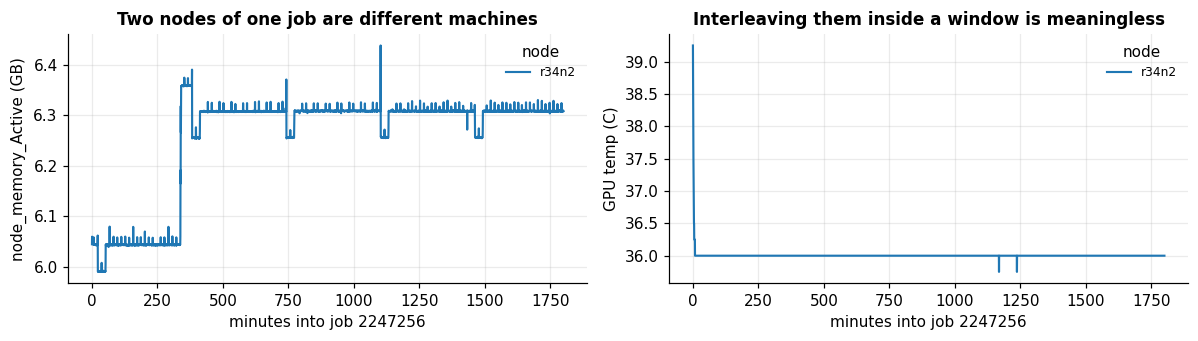

In [6]:
print("jobs by number of allocated nodes seen in the telemetry:")
print(jt["n_nodes"].value_counts().sort_index().to_string())
multi = jt[jt.n_nodes > 1]
in_multi = sc["slurm_id"].isin(set(multi.slurm_id))
print(f"\n{len(multi)} multi-node jobs, {in_multi.sum():,} snapshots ({in_multi.mean():.2%})")
print(f"unique (slurm_id, timestamp)       : {len(sc.drop_duplicates(['slurm_id','timestamp'])):,}")
print(f"unique (slurm_id, node, timestamp) : "
      f"{len(sc.drop_duplicates(['slurm_id','node','timestamp'])):,}   <- the real key")
print(f"series (job x node): {sc['series_id'].nunique():,}")
AUDIT["multi_node_jobs"] = int(len(multi)); AUDIT["n_series"] = int(sc["series_id"].nunique())

ex = int(multi.sort_values("n_snap", ascending=False).iloc[0].slurm_id)
part = int(jt.loc[jt.slurm_id == ex, "last_part"].iloc[0])
t = pq.read_table(files[part], columns=["slurm_id", "node", "timestamp",
                                        "node_memory_Active_bytes",
                                        "nvidia_gpu_temperature_celsius_mean"])
d = t.filter(pc.field("slurm_id") == ex).to_pandas().sort_values(["timestamp", "node"])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for n, grp in d.groupby("node", observed=True):
    mm = (grp.timestamp - d.timestamp.min()).dt.total_seconds() / 60
    axes[0].plot(mm, grp.node_memory_Active_bytes / 1e9, label=n, lw=1.4)
    axes[1].plot(mm, grp.nvidia_gpu_temperature_celsius_mean, label=n, lw=1.4)
axes[0].set_ylabel("node_memory_Active (GB)"); axes[1].set_ylabel("GPU temp (C)")
for a in axes:
    a.set_xlabel(f"minutes into job {ex}"); a.legend(title="node", fontsize=8)
axes[0].set_title("Two nodes of one job are different machines")
axes[1].set_title("Interleaving them inside a window is meaningless")
fig.savefig(pv2.FIGURES / "01_multinode.png", bbox_inches="tight")
plt.show()

## 5. Finding 4 — the 40-snapshot window deletes most failures

This is the important one.

A series needs at least 40 snapshots (20 minutes) to produce a single window. Failure jobs are *short*:
the median `FAILED` job in this dataset lives **30 seconds**. So the window requirement does not thin the
population uniformly — it removes the failures and keeps the survivors.

In [7]:
jt["dur_h"] = (jt["last_ts"] - jt["first_ts"]).dt.total_seconds() / 3600
dur = jt.groupby("state", observed=True)["dur_h"].describe(percentiles=[.25, .5, .75, .9])
print("monitored duration in hours, by state:")
print(dur[["count", "25%", "50%", "75%", "90%", "max"]].round(3).to_string())

# a series (job x node) is what must reach 40 snapshots
ser_len = pd.DataFrame({"n": ends - starts, "slurm_id": jid[starts]}).merge(
    jt[["slurm_id", "state"]], on="slurm_id", how="left")
rows = []
for W in (10, 20, 40, 60):
    rows.append((1 - ser_len.assign(k=ser_len.n >= W)
                 .groupby("state", observed=True)["k"].mean()).rename(f"W={W}"))
drop = pd.concat(rows, axis=1)
drop.index = [pv2.STATE_DISPLAY[s] for s in drop.index]
print("\nfraction of series DROPPED (too short to make even one window):")
print(drop.map(lambda v: f"{v:6.1%}").to_string())
AUDIT["drop_fraction_W40"] = {i: float(v) for i, v in drop["W=40"].items()}

monitored duration in hours, by state:
                 count    25%    50%     75%     90%      max
state                                                        
COMPLETED      17306.0  0.125  0.850   1.900   7.400  119.025
FAILED          4664.0  0.000  0.008   0.075   0.856   92.500
NODE_FAIL        107.0  0.150  0.158   0.575   1.825   24.392
OUT_OF_MEMORY    130.0  0.069  0.183   1.390   5.739   90.375
TIMEOUT         1411.0  1.000  4.992  30.000  64.000  120.000



fraction of series DROPPED (too short to make even one window):
             W=10    W=20    W=40    W=60
COMPLETED   21.7%   26.1%   37.5%   41.7%
FAILED      73.1%   81.4%   84.8%   86.9%
NODE_FAIL   16.1%   28.6%   67.0%   74.1%
OOM         25.4%   47.7%   56.2%   60.8%
TIMEOUT      0.7%    5.8%    8.8%   10.2%


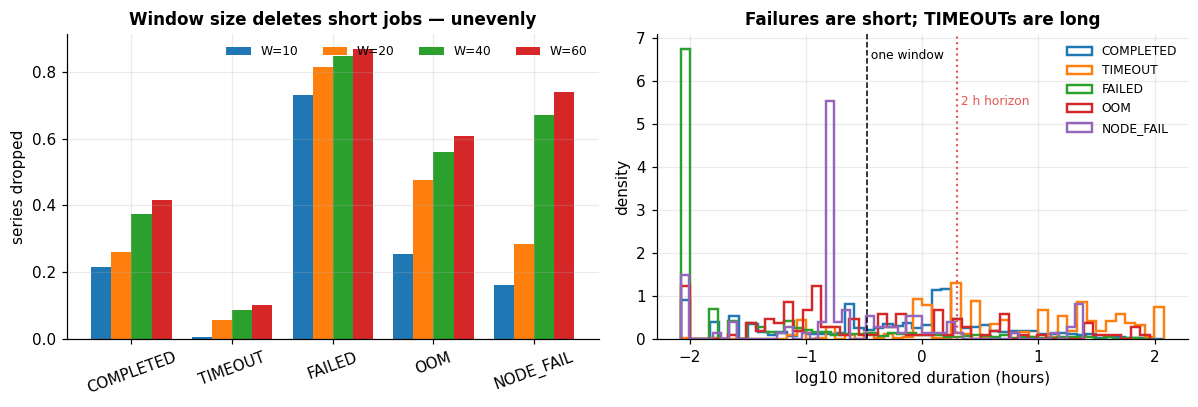

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
order = ["COMPLETED", "TIMEOUT", "FAILED", "OUT_OF_MEMORY", "NODE_FAIL"]
lbl = [pv2.STATE_DISPLAY[s] for s in order]

ax = axes[0]
x = np.arange(len(order)); w = 0.2
for i, W in enumerate((10, 20, 40, 60)):
    v = [1 - (ser_len.loc[ser_len.state == s, "n"] >= W).mean() for s in order]
    ax.bar(x + (i - 1.5) * w, v, w, label=f"W={W}")
ax.set_xticks(x); ax.set_xticklabels(lbl, rotation=20)
ax.set_ylabel("series dropped"); ax.set_title("Window size deletes short jobs — unevenly")
ax.legend(ncol=4, fontsize=8)

ax = axes[1]
for s in order:
    dd = jt.loc[jt.state == s, "dur_h"].clip(lower=1/120)
    ax.hist(np.log10(dd), bins=50, histtype="step", density=True,
            label=pv2.STATE_DISPLAY[s], lw=1.6)
ax.axvline(np.log10(pv2.WINDOW * 30 / 3600), color="k", ls="--", lw=1)
ax.text(np.log10(pv2.WINDOW * 30 / 3600), ax.get_ylim()[1] * .95, " one window",
        fontsize=8, va="top")
ax.axvline(np.log10(pv2.HORIZON_H), color=pv2.PALETTE["accent"], ls=":", lw=1.4)
ax.text(np.log10(pv2.HORIZON_H), ax.get_ylim()[1] * .8, " 2 h horizon", fontsize=8,
        va="top", color=pv2.PALETTE["accent"])
ax.set_xlabel("log10 monitored duration (hours)"); ax.set_ylabel("density")
ax.set_title("Failures are short; TIMEOUTs are long"); ax.legend(fontsize=8)
fig.savefig(pv2.FIGURES / "01_window_size_vs_jobs.png", bbox_inches="tight")
plt.show()

At **W=40** the pipeline throws away **~85 % of `FAILED` series, ~65 % of `NODE_FAIL` and ~56 % of `OOM`**,
but only ~37 % of `COMPLETED` and **~9 % of `TIMEOUT`**. That single mechanical choice is why `TIMEOUT`
supplied ~70 % of all positive windows in Sessions 1–2: the other failure modes were filtered out of the
problem before any model saw them. It is also a plausible part of why per-state recall was worst for
`NODE_FAIL` — that class had been thinned hardest.

Notebook 05 measures what smaller windows do to this.

## 6. Finding 5 — with a 2 h horizon, most failure jobs are positive end to end

A window is labelled positive when it falls in the last `HORIZON_H` hours of a failing job. But **79 % of
failure jobs do not last two hours**, so for those, every window is positive: inside such a job there is no
"healthy" stretch to contrast with the "about to fail" stretch.

The task is still per-window early prediction — the model never sees a job-level aggregate, and no window
knows how near the end it is. But for short jobs the *label* effectively says "this job will fail", and the
discrimination to be learned is between jobs rather than within them. Worth stating plainly in the thesis,
and worth testing: a shorter horizon restores within-job contrast at the cost of fewer positives.

In [9]:
f = jt[jt.is_failure]
short = f.dur_h < pv2.HORIZON_H
print(f"failure jobs shorter than the {pv2.HORIZON_H:.0f} h horizon: {short.mean():.1%}\n")
tab = pd.DataFrame({"jobs": f.groupby("state", observed=True).size(),
                    "shorter_than_horizon":
                        f.assign(s=short).groupby("state", observed=True)["s"].mean()}).dropna()
tab.index = [pv2.STATE_DISPLAY[s] for s in tab.index]
print(tab.assign(shorter_than_horizon=lambda d: d.shorter_than_horizon.map("{:.1%}".format))
        .to_string())
AUDIT["failure_jobs_shorter_than_horizon"] = float(short.mean())
print()
for H in (0.25, 0.5, 1.0, 2.0):
    print(f"  horizon {H:>4} h -> {(f.dur_h < H).mean():.1%} of failure jobs lie entirely inside it")

failure jobs shorter than the 2 h horizon: 78.7%

           jobs shorter_than_horizon
FAILED     4664                92.9%
NODE_FAIL   107                89.7%
OOM         130                77.7%
TIMEOUT    1411                30.8%

  horizon 0.25 h -> 65.5% of failure jobs lie entirely inside it
  horizon  0.5 h -> 68.9% of failure jobs lie entirely inside it
  horizon  1.0 h -> 74.2% of failure jobs lie entirely inside it
  horizon  2.0 h -> 78.7% of failure jobs lie entirely inside it


### Exact window counts and the label mix

Window mechanics are cheap on timestamps alone, so the labels can be counted for several window sizes
*before* any feature matrix exists. These numbers are the targets notebook 02 has to reproduce.

In [10]:
end_ns = {int(k): np.int64(v.value) for k, v in jt.set_index("slurm_id")["end_date"].items()}
fail_set = set(jt.loc[jt.is_failure, "slurm_id"].astype(int))
state_of = {int(k): str(v) for k, v in jt.set_index("slurm_id")["state"].items()}
split_of = {int(k): v for k, v in jt.set_index("slurm_id")["split"].items()}
horizon_s = pv2.HORIZON_H * 3600

def label_census(W, stride_train=1, stride_test=1):
    rec = {}
    for s0, e0 in zip(starts, ends):
        j = int(jid[s0]); sp = split_of[j]
        t = ts[s0:e0]
        st = pv2.valid_window_starts(t, W, stride_train if sp == "train" else stride_test)
        if len(st) == 0:
            continue
        ttf = (end_ns[j] - t) / 1e9
        pos = (((ttf >= 0) & (ttf <= horizon_s)).astype(np.int32) if j in fail_set
               else np.zeros(len(t), np.int32))
        cs = np.concatenate([[0], np.cumsum(pos)])
        y = (cs[st + W] - cs[st] >= W / 2)
        a = rec.setdefault((sp, state_of[j]), [0, 0])
        a[0] += len(st); a[1] += int(y.sum())
    return rec

census = {}
for W in (10, 40):
    t0 = time.time(); census[W] = label_census(W)
    df = pd.DataFrame([(sp, pv2.STATE_DISPLAY[st], n, p)
                       for (sp, st), (n, p) in census[W].items()],
                      columns=["split", "state", "windows", "positives"])
    tot = df.groupby("split")[["windows", "positives"]].sum()
    tot["pos_fraction"] = tot.positives / tot.windows
    print(f"=== W = {W} ({W*30/60:.0f} min), stride 1   [{time.time()-t0:.0f}s] ===")
    print(tot.assign(windows=tot.windows.map("{:,}".format),
                     positives=tot.positives.map("{:,}".format),
                     pos_fraction=tot.pos_fraction.map("{:.4f}".format)).to_string())
    piv = df[df.split == "test"].set_index("state")[["windows", "positives"]].sort_values(
        "positives", ascending=False)
    piv["share_of_positives"] = (piv.positives / piv.positives.sum()).map("{:.1%}".format)
    print(piv.assign(windows=piv.windows.map("{:,}".format),
                     positives=piv.positives.map("{:,}".format)).to_string(), "\n")
AUDIT["census"] = {str(W): {f"{sp}|{st}": v for (sp, st), v in rec.items()}
                   for W, rec in census.items()}

=== W = 10 (5 min), stride 1   [3s] ===
         windows positives pos_fraction
split                                  
test   1,497,018    66,892       0.0447
train  9,472,741   331,967       0.0350
           windows positives share_of_positives
state                                          
TIMEOUT    415,494    44,989              67.3%
FAILED      56,076    16,379              24.5%
NODE_FAIL   24,076     3,329               5.0%
OOM          2,254     2,195               3.3%
COMPLETED  999,118         0               0.0% 



=== W = 40 (20 min), stride 1   [3s] ===
         windows positives pos_fraction
split                                  
test   1,407,162    56,527       0.0402
train  9,105,240   291,384       0.0320
           windows positives share_of_positives
state                                          
TIMEOUT    407,039    39,780              70.4%
FAILED      51,683    12,674              22.4%
NODE_FAIL   23,003     2,481               4.4%
OOM          1,606     1,592               2.8%
COMPLETED  923,831         0               0.0% 



The `W=40` line is the population Sessions 1–2 trained and tested on: ~9.1 M train and ~1.41 M test
windows, and a **test positive fraction of ~0.040 — the PR-AUC baseline quoted there**. Reproducing it
from scratch confirms the rebuilt window mechanics agree with the old pipeline (small differences come
from the gap guard and from splitting multi-node jobs per node).

At `W=10` far more windows survive, and the failure states that `W=40` had deleted return to the positives.

## 7. Finding 6 — three of the eight inherited features are cumulative counters

Session 1 inherited eight metrics from Skrzeczek's thesis. Three of them —
`node_disk_written_bytes_total_sum`, `node_forks_total`, `node_netstat_Tcp_InErrs` — are **monotonically
increasing counters**: totals since the node booted.

Summarised inside a 20-minute window, a counter's `min`/`max`/`mean` say very little about what is
happening now; they mostly encode **how long the node has been up**. What an operator would actually want
is the *rate*: bytes per second, forks per second, errors per second. The counter's `std` carries a smeared
version of that, which is presumably why these features were not useless.

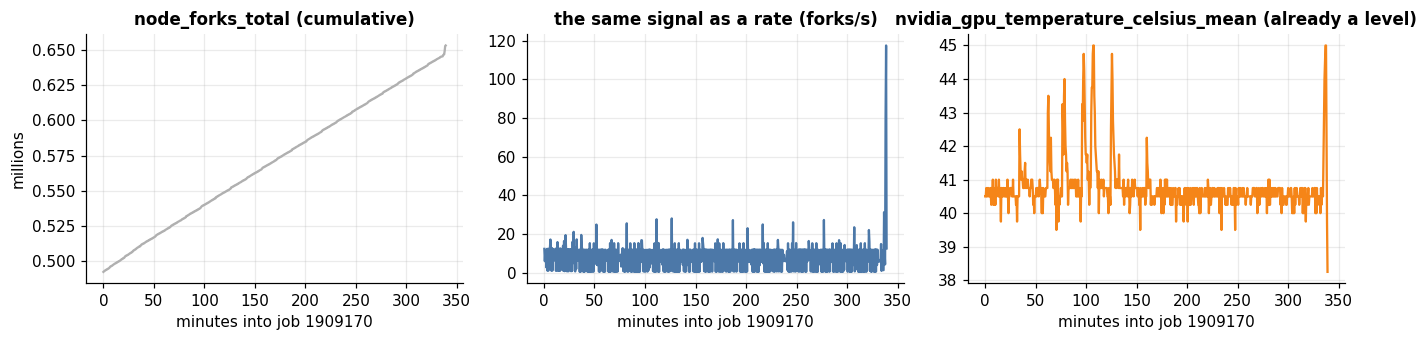

inside a 40-snapshot window, node_forks_total varies by 1.55% of its own level (median over windows)


In [11]:
gpu_parts = sorted(jt["last_part"].unique())
sample_parts = gpu_parts[len(gpu_parts)//2: len(gpu_parts)//2 + 12]
demo = jt[(jt.n_snap.between(600, 2000)) & (jt.state == "COMPLETED") & (jt.n_nodes == 1)].iloc[0]
t = pq.read_table(files[int(demo.last_part)],
                  columns=["slurm_id", "timestamp", "node_forks_total",
                           "node_disk_written_bytes_total_sum",
                           "nvidia_gpu_temperature_celsius_mean"])
d = t.filter(pc.field("slurm_id") == int(demo.slurm_id)).to_pandas().sort_values("timestamp")
mm = (d.timestamp - d.timestamp.iloc[0]).dt.total_seconds() / 60

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.2))
axes[0].plot(mm, d.node_forks_total / 1e6, color=pv2.PALETTE["muted"])
axes[0].set_title("node_forks_total (cumulative)"); axes[0].set_ylabel("millions")
rate = np.r_[np.nan, np.diff(d.node_forks_total) / np.diff(mm * 60)]
axes[1].plot(mm, rate, color=pv2.PALETTE["rate"])
axes[1].set_title("the same signal as a rate (forks/s)")
axes[2].plot(mm, d.nvidia_gpu_temperature_celsius_mean, color=pv2.PALETTE["gpu"])
axes[2].set_title("nvidia_gpu_temperature_celsius_mean (already a level)")
for a in axes:
    a.set_xlabel(f"minutes into job {int(demo.slurm_id)}")
fig.savefig(pv2.FIGURES / "01_counter_vs_rate.png", bbox_inches="tight")
plt.show()

roll = d.node_forks_total.rolling(pv2.WINDOW)
print(f"inside a {pv2.WINDOW}-snapshot window, node_forks_total varies by "
      f"{(roll.max() - roll.min()).median() / d.node_forks_total.median():.2%} of its own level "
      "(median over windows)")

The left panel is a near-straight line: over 20 minutes the counter's variation is a rounding error on its
absolute level, so a tree splitting on it is largely splitting on node uptime. The middle panel is the same
data as a rate and is full of structure. Rung B of the ablation (notebook 03) tests exactly this swap.

## 8. Finding 7 — one inherited feature is very nearly constant, and better ones went unused

In [12]:
cols = ["node_netstat_Tcp_InErrs", "node_forks_total", "node_memory_Active_bytes",
        "nvidia_gpu_duty_cycle_mean", "node_procs_blocked", "node_memory_MemFree_bytes",
        "node_filesystem_device_error_sum", "node_netstat_Udp_InErrors"]
smp = []
for p in [files[int(i)] for i in sample_parts]:
    t = pq.read_table(p, columns=cols + ["gpu_node", "state"])
    t = t.filter((pc.field("gpu_node") == 1) & (pc.field("state") != "CANCELLED"))
    if t.num_rows:
        smp.append(t.drop_columns(["gpu_node", "state"]).to_pandas())
smp = pd.concat(smp, ignore_index=True)
prof = pd.DataFrame({"distinct_values": smp.nunique(), "std": smp.std(),
                     "share_at_mode": smp.apply(lambda s: s.value_counts(normalize=True).iloc[0])})
prof = prof.sort_values("distinct_values")
print(prof.assign(std=prof["std"].map("{:.3g}".format),
                  share_at_mode=prof.share_at_mode.map("{:.2%}".format)).to_string())
print(f"\n(profiled on {len(smp):,} GPU snapshots)")
AUDIT["tcp_inerrs_distinct"] = int(prof.loc["node_netstat_Tcp_InErrs", "distinct_values"])

                                  distinct_values       std share_at_mode
node_filesystem_device_error_sum                1         0       100.00%
node_netstat_Udp_InErrors                       1         0       100.00%
node_netstat_Tcp_InErrs                         7      1.02        88.56%
node_procs_blocked                             54      0.81        96.40%
nvidia_gpu_duty_cycle_mean                    401      29.7         6.73%
node_memory_MemFree_bytes                  278666  5.14e+10         0.01%
node_memory_Active_bytes                   880944  2.57e+10         0.01%
node_forks_total                           996847  5.35e+06         0.00%

(profiled on 4,517,890 GPU snapshots)


`node_netstat_Tcp_InErrs` takes a handful of distinct values across millions of snapshots — one of the
eight inherited features is nearly a constant, yet it contributes four of the 32 columns Sessions 1–2
trained on. Two other error counters in the dump (`node_filesystem_device_error_sum`,
`node_netstat_Udp_InErrors`) are *exactly* constant here and are excluded from the new metric set for that
reason.

Meanwhile `nvidia_gpu_duty_cycle_mean` — GPU utilisation, an obvious signal for a stalled or dying job —
was never used, and neither were free memory, blocked processes, or the per-GPU temperature spread.

## 9. Finding 8 — the nodes are not interchangeable

51 GPU nodes, and they are not the same hardware running the same work. A given temperature or memory
level means different things on different nodes, so an absolute threshold learned across all of them is a
compromise. What carries health information is the **departure from that node's own normal**.

       snapshots  temp_median  temp_sd    mem_median
node                                                
r31n6      20995        34.50     9.76  1.282080e+10
r32n7      10165        35.50    14.15  8.813220e+09
r32n2     203281        39.25    11.12  1.662550e+10
r32n6     184090        41.75    11.53  1.662810e+10
r32n3     212381        43.00    10.19  1.625470e+10 
   ...

       snapshots  temp_median  temp_sd    mem_median
node                                                
r34n4     259792        69.50    13.30  2.217480e+10
r34n6     273109        70.25    16.16  2.737110e+10
r33n6      50640        70.75    14.00  2.990810e+10
r34n3     183157        73.25    13.87  3.146160e+10
r34n2     261495        74.75    15.02  1.851830e+10

median GPU temperature across nodes spans 40.2 C of ordinary operation


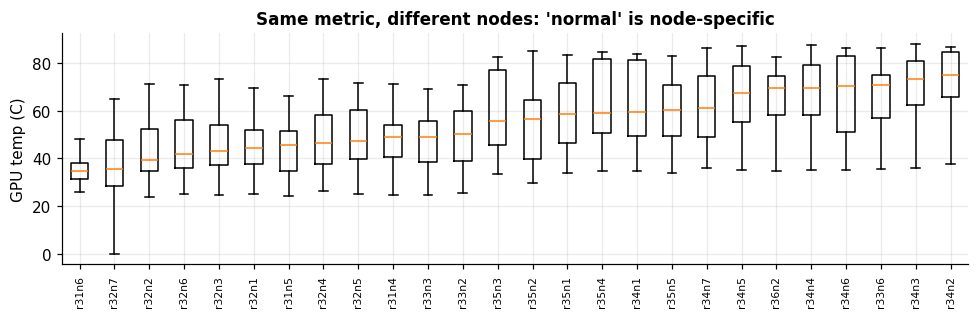

In [13]:
smp2 = []
for p in [files[int(i)] for i in sample_parts]:
    t = pq.read_table(p, columns=["node", "gpu_node", "state",
                                  "nvidia_gpu_temperature_celsius_mean",
                                  "node_memory_Active_bytes"])
    t = t.filter((pc.field("gpu_node") == 1) & (pc.field("state") != "CANCELLED"))
    if t.num_rows:
        smp2.append(t.drop_columns(["gpu_node", "state"]).to_pandas())
smp2 = pd.concat(smp2, ignore_index=True)
g = smp2.groupby("node", observed=True)
summ = g.agg(snapshots=("nvidia_gpu_temperature_celsius_mean", "size"),
             temp_median=("nvidia_gpu_temperature_celsius_mean", "median"),
             temp_sd=("nvidia_gpu_temperature_celsius_mean", "std"),
             mem_median=("node_memory_Active_bytes", "median")).sort_values("temp_median")
print(summ.head(5).round(2).to_string(), "\n   ...\n")
print(summ.tail(5).round(2).to_string())
spread = float(summ.temp_median.max() - summ.temp_median.min())
print(f"\nmedian GPU temperature across nodes spans {spread:.1f} C of ordinary operation")
AUDIT["node_temp_median_spread"] = spread

fig, ax = plt.subplots(figsize=(9, 3))
ns = summ.index.tolist()
ax.boxplot([smp2.loc[smp2.node == n, "nvidia_gpu_temperature_celsius_mean"] for n in ns],
           tick_labels=ns, showfliers=False)
ax.set_ylabel("GPU temp (C)")
ax.set_title("Same metric, different nodes: 'normal' is node-specific")
plt.xticks(rotation=90, fontsize=7)
fig.savefig(pv2.FIGURES / "01_node_heterogeneity.png", bbox_inches="tight")
plt.show()

Rung E of the ablation re-expresses every feature as a deviation from its node's own baseline (computed
from **training** snapshots only) and measures whether that helps.

## 10. What this audit decides

| # | Measured | Decision for the rebuilt pipeline | Tested in |
|---|---|---|---|
| 1 | cadence is 30 s, not 15 s | a 40-snapshot window is **20 min**; slopes per second, lead times in minutes | nb 02 |
| 2 | a few windows straddle gaps | **reject windows with any gap > 60 s** → even grid → exact re-labelling at any horizon | nb 02 |
| 3 | 123 jobs span several nodes and their rows interleave | window the **(job, node) series**, group by job for CV | nb 02 |
| 4 | W=40 drops ~85 % of `FAILED`, ~65 % of `NODE_FAIL` | keep W=40 for the *feature* work (comparability), then **vary the window** | nb 05 |
| 5 | 79 % of failure jobs are shorter than the 2 h horizon | keep 2 h as primary, **vary the horizon** — no rebuild needed | nb 05 |
| 6 | 3 of the 8 inherited metrics are cumulative counters | add **rate** versions of every counter | nb 03 (B) |
| 7 | one inherited metric is near-constant; duty cycle unused | **expand to 39 metrics**, excluding the exactly-constant ones | nb 03 (C) |
| 8 | node baselines differ by tens of degrees | add **per-node normalisation** as an option | nb 03 (E) |
| 9 | ~3 % of test snapshots predate the split boundary | keep the job-level split for comparability, **test a strict time split** | nb 05 |
| — | `min/max/mean/std` discard the trajectory | add **last / delta / slope** | nb 03 (D) |

Notebook 02 builds the dataset all of this needs.

In [14]:
(pv2.RESULTS / "audit.json").write_text(json.dumps(AUDIT, indent=2, default=str), encoding="utf-8")
print("saved", pv2.RESULTS / "audit.json")
print(json.dumps({k: v for k, v in AUDIT.items() if k != "census"}, indent=2, default=str))

saved D:\_fcall\UNIFEI\tcc\hpc_workload\pipeline_v2\results\audit.json
{
  "n_snapshots": 11144842,
  "n_jobs": 23618,
  "n_nodes": 51,
  "span": [
    "2022-08-25 10:27:00",
    "2022-11-01 13:58:00"
  ],
  "split_time": "2022-10-19 11:50:16",
  "n_train_jobs": 18894,
  "n_test_jobs": 4724,
  "test_jobs_starting_before_split": 36,
  "test_snapshots_before_split": 0.030628646189682817,
  "cadence_s": 30.0,
  "window_minutes": 20.0,
  "series_with_gap": 540,
  "gap_interval_share": 5.485083719462246e-05,
  "multi_node_jobs": 123,
  "n_series": 23772,
  "drop_fraction_W40": {
    "COMPLETED": 0.3750430687952222,
    "FAILED": 0.8477103301384452,
    "NODE_FAIL": 0.6696428571428572,
    "OOM": 0.5615384615384615,
    "TIMEOUT": 0.08796622097114704
  },
  "failure_jobs_shorter_than_horizon": 0.7869138149556401,
  "tcp_inerrs_distinct": 7,
  "node_temp_median_spread": 40.25
}
